# Sentiment Analysis on IMDB Movie Reviews

## Objective

The objective of this project is to analyze movie reviews from the IMDB dataset and determine whether the sentiments expressed are positive or negative. Various text preprocessing and visualization techniques are used to gain insights into customer opinions.

In [2]:

!pip install textblob

   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/626.3 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 626.3/626.3 kB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.7 MB/s eta 0:00:00


In [5]:
!pip install wordcloud

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

In [9]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df.shape

(50000, 2)

In [13]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [15]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [16]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Dataset Observation

The dataset contains movie reviews and their corresponding sentiment labels.

The sentiment column consists of two classes:
- Positive
- Negative

The dataset will be analyzed to understand the distribution of sentiments and extract meaningful insights.

## Sentiment Distribution Observation

The dataset contains an equal number of positive and negative reviews.

- Positive Reviews: 25,000
- Negative Reviews: 25,000

This balanced distribution helps prevent bias during sentiment analysis and ensures reliable results.

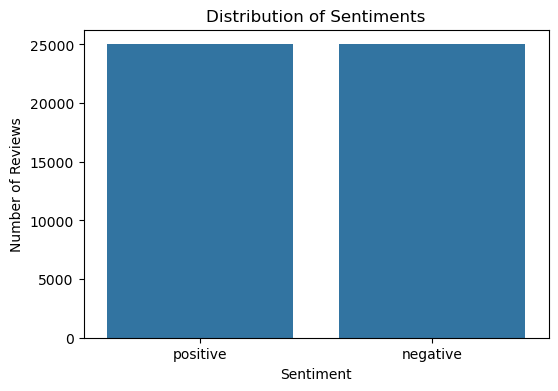

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Insight

The sentiment distribution is perfectly balanced, with 25,000 positive reviews and 25,000 negative reviews.

This indicates that the dataset provides equal representation of both sentiment classes, making it suitable for sentiment analysis tasks.

In [18]:
df['review_length'] = df['review'].apply(len)

In [19]:
df[['review','review_length']].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926
3,Basically there's a family where a little boy ...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317


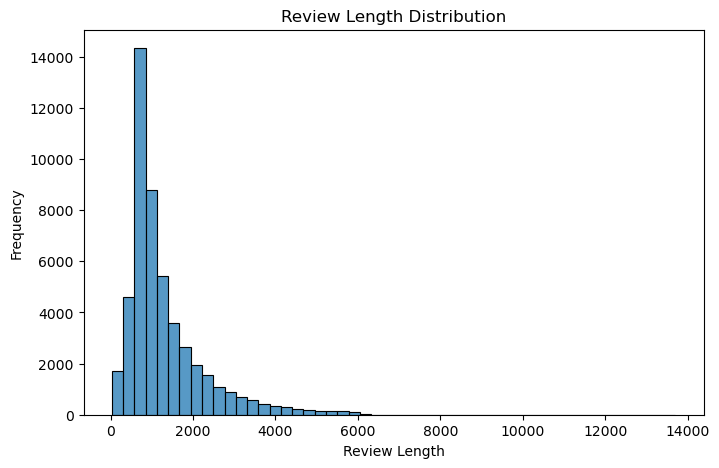

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

### Insight

Review lengths vary significantly across the dataset.

While many reviews are of moderate length, some reviews are considerably longer, indicating detailed user opinions and experiences.

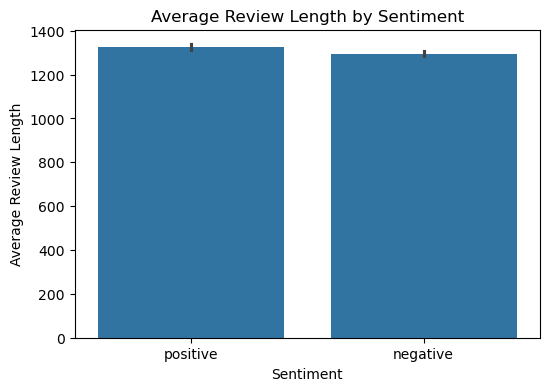

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='sentiment',
    y='review_length',
    data=df
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")

plt.show()

### Insight

This visualization compares the average length of positive and negative reviews.

Differences in review length may indicate varying levels of user engagement and emotional expression.

In [23]:
df.groupby('sentiment')['review_length'].mean()

sentiment
negative    1294.06436
positive    1324.79768
Name: review_length, dtype: float64

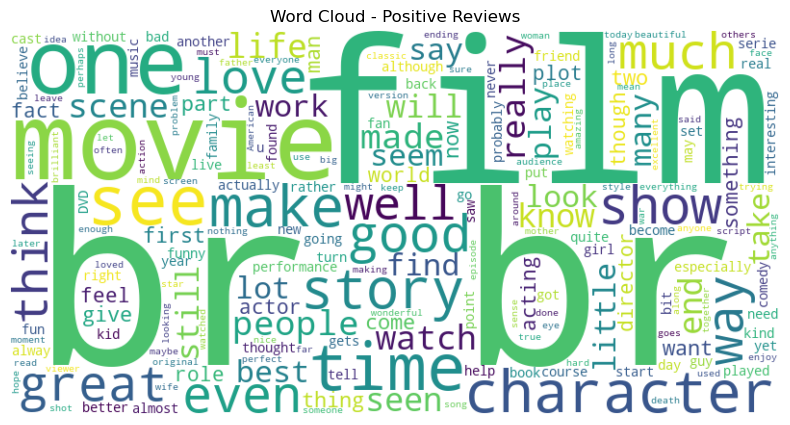

In [24]:
positive_reviews = " ".join(
    df[df['sentiment']=='positive']['review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Positive Reviews")
plt.show()

### Insight

The positive review word cloud highlights the most frequently occurring words in positive movie reviews.

Larger words represent terms that appear more frequently, helping identify themes associated with positive viewer experiences.

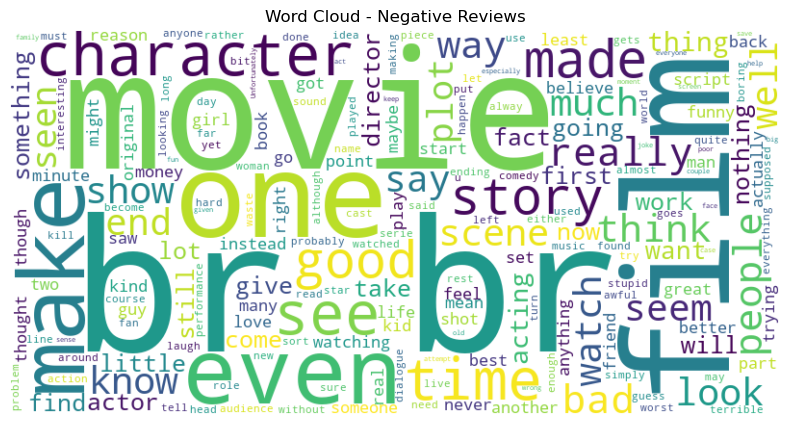

In [25]:
negative_reviews = " ".join(
    df[df['sentiment']=='negative']['review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Negative Reviews")
plt.show()

### Insight

The negative review word cloud displays the most common words used in negative movie reviews.

These terms help reveal common complaints, criticisms, and negative viewer experiences.

In [27]:
df['polarity'] = df['review'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [28]:
df[['sentiment','polarity']].head()

,sentiment,polarity
0,positive,0.023433
1,positive,0.109722
2,positive,0.354008
3,negative,-0.057813
4,positive,0.217952


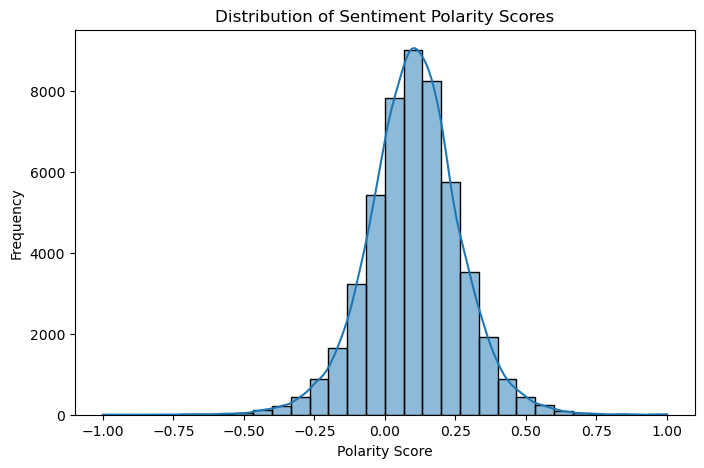

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['polarity'],
    bins=30,
    kde=True
)

plt.title("Distribution of Sentiment Polarity Scores")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")

plt.show()

### Insight

Polarity scores range from -1 to +1.

Negative values indicate negative sentiment, while positive values indicate positive sentiment.

The distribution provides an overview of emotional intensity across reviews.

# Conclusion

1. The IMDB dataset contains 50,000 movie reviews with equal numbers of positive and negative reviews.

2. No missing values were found, indicating high-quality data.

3. Positive and negative reviews are nearly equal in length, suggesting that users provide detailed feedback regardless of sentiment.

4. Word clouds revealed frequently occurring terms associated with positive and negative opinions.

5. Sentiment polarity analysis helped quantify emotional expression within reviews.

6. Sentiment analysis is a powerful technique for understanding customer opinions and can support decision-making in entertainment, marketing, and recommendation systems.